Import

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [14]:
import zipfile
import os

zip_path = "/content/Copy of devnagari digit (2).zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed")

print(os.listdir("/content/"))

Extraction Completed
['.config', 'DevanagariHandwrittenDigitDataset', 'Copy of devnagari digit (2).zip', 'sample_data']


Load the Dataset

In [8]:
import os
from PIL import Image
import numpy as np

# Correct dataset path
dataset_path = "/content/DevanagariHandwrittenDigitDataset/Train"

IMG_SIZE = 32
images = []

for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)

    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))

            except Exception as e:
                print(f"Skipped: {img_path} - {e}")

images = np.array(images)

print("Total images loaded:", images.shape)

Total images loaded: (17000, 32, 32)


 Normalize & Reshape

In [15]:
#Normalize
images = images.astype('float32') / 255.

# Reshape
images = np.reshape(images, (len(images), IMG_SIZE, IMG_SIZE, 1))

print(f"Images shape after reshape: {images.shape}")

Images shape after reshape: (17000, 32, 32, 1)


Split (Train and Validation Sets)

In [16]:
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)

print(f"Training set   : {x_train.shape}")
print(f"Validation set : {x_val.shape}")

Training set   : (13600, 32, 32, 1)
Validation set : (3400, 32, 32, 1)


Visualize Original vs Noisy Images

In [17]:
import numpy as np

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

# Clip values to keep them valid (0–1)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

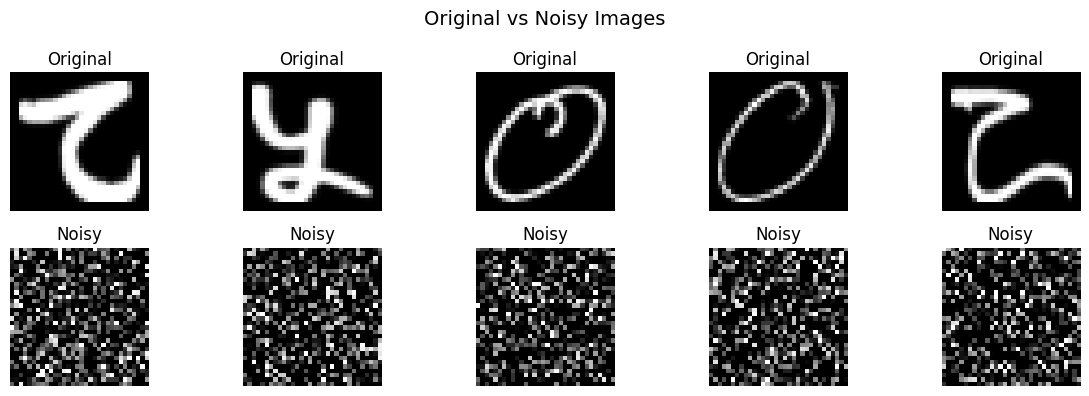

In [18]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(12, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

 Build the Encoder (4 layers deep)

In [19]:
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="encoder_input")

    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 32x32 → 16x16

    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 16x16 → 8x8

    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 8x8 → 4x4

    # Layer 4
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="latent_space")(x)  # 4x4 → 2x2

    return input_img, encoded

print("Encoder built")

Encoder built


Build the Decoder (4 layers deep)

In [20]:
def build_decoder(encoded_input):

    # Layer 1
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    # Layer 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    # Layer 3
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    # Layer 4
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    # Output layer
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoder_output")(x)

    return decoded

print("Decoder built")

Decoder built


Combine into Full Autoencoder

In [22]:
def build_autoencoder(input_shape=(32, 32, 1)):
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
print("Full Autoencoder built")

Full Autoencoder built


Compile the Model

In [23]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,505 (5.21 MB)

 Trainable params: 1,365,505 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

Train the Autoencoder

In [24]:
import numpy as np

# Normalize validation
x_val = x_val.astype('float32') / 255.0

noise_factor = 0.5
x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_val.shape
)

x_val_noisy = np.clip(x_val_noisy, 0., 1.)

In [25]:
EPOCHS = 20
BATCH_SIZE = 64

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

print("Training Completed")

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 140s 636ms/step - loss: 0.0203 - val_loss: 0.0011
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 134s 595ms/step - loss: 0.0073 - val_loss: 8.3021e-04
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 598ms/step - loss: 0.0073 - val_loss: 0.0011
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 128s 602ms/step - loss: 0.0073 - val_loss: 0.0012
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 146s 620ms/step - loss: 0.0073 - val_loss: 8.3156e-04
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 132s 622ms/step - loss: 0.0073 - val_loss: 0.0010
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 129s 606ms/step - loss: 0.0073 - val_loss: 9.8273e-04
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 132s 622ms/step - loss: 0.0073 - val_loss: 0.0011
Epoch 9/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 143s 629ms/step - loss: 0.0073 - val_loss: 9.1022e-04
Epoch 10/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 128s 601ms/step - loss: 0.0073 - val_loss: 0.0013
Epoch 11/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 125s 589ms/step - loss: 0.0073 - val_loss:

Plot Training & Validation Loss

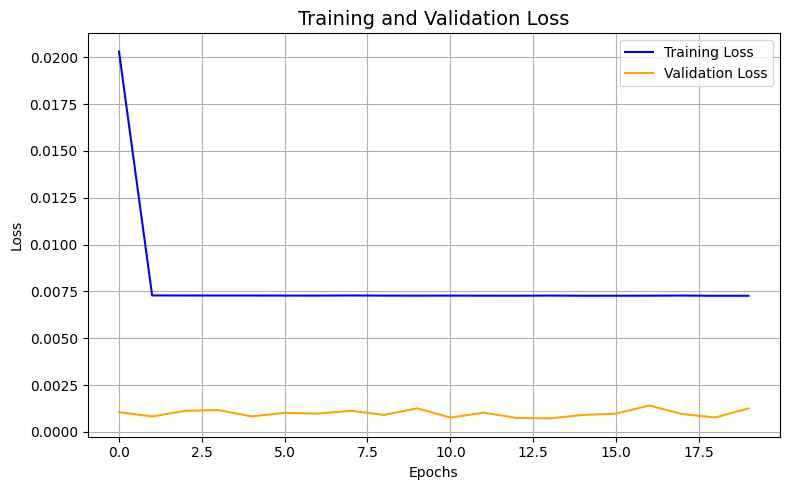

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Predict Denoised Images

In [27]:
denoised_images = autoencoder.predict(x_val_noisy)
print(f"Denoised images shape: {denoised_images.shape}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step
Denoised images shape: (3400, 32, 32, 1)


Visualize Noisy vs Denoised vs Clean

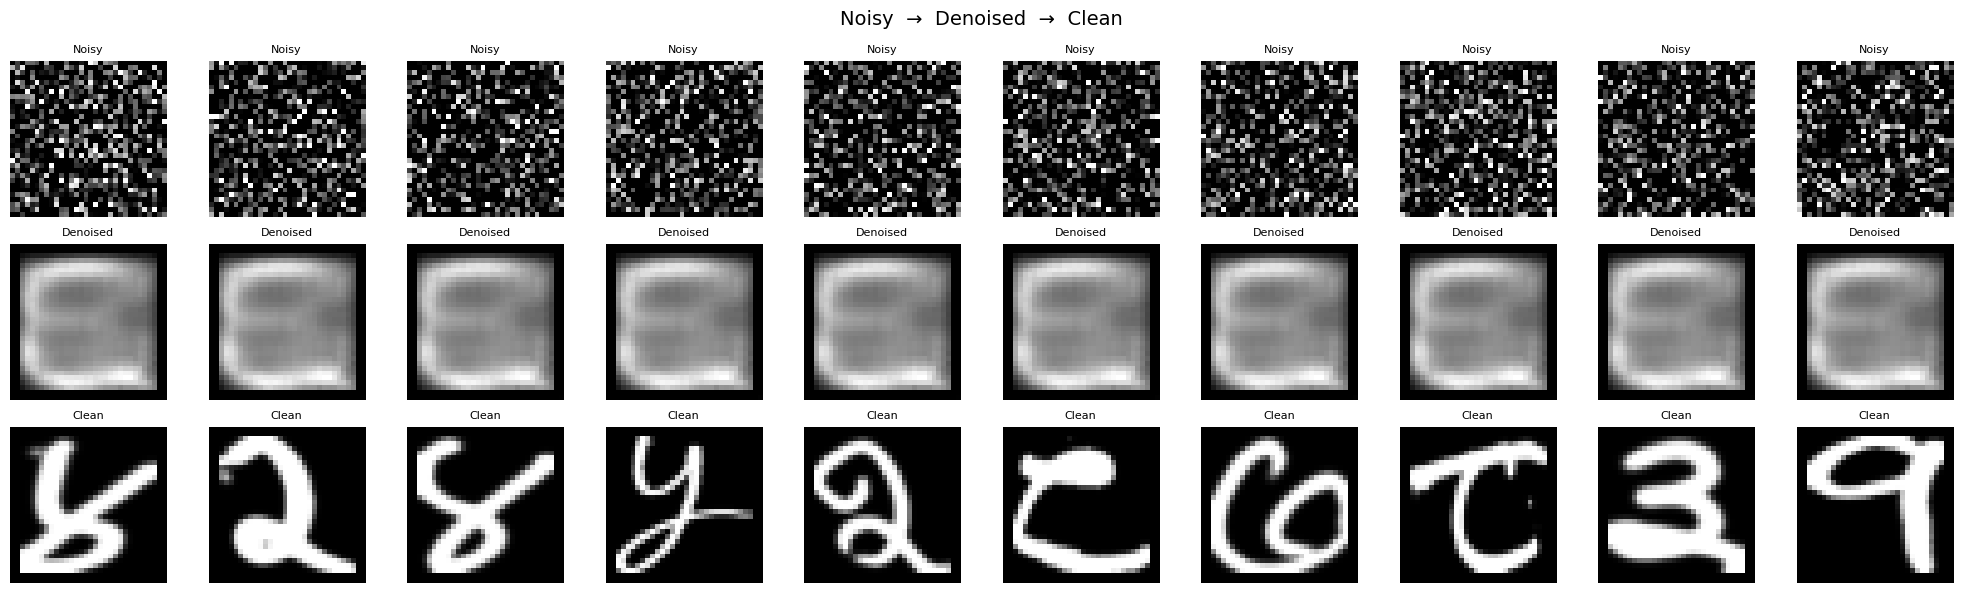

In [28]:
def plot_results(noisy, denoised, clean, n=10, img_size=32):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Row 1: Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Noisy", fontsize=8)
        plt.axis('off')

        # Row 2: Denoised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Denoised", fontsize=8)
        plt.axis('off')

        # Row 3: Clean
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Clean", fontsize=8)
        plt.axis('off')

    plt.suptitle("Noisy  →  Denoised  →  Clean", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_results(x_val_noisy, denoised_images, x_val, n=10)

Save the Model

In [29]:
autoencoder.save("devnagari_denoising_autoencoder.keras")
print("Model saved")

Model saved


Experiment: Try Different Noise Levels


Noise Factor: 0.1


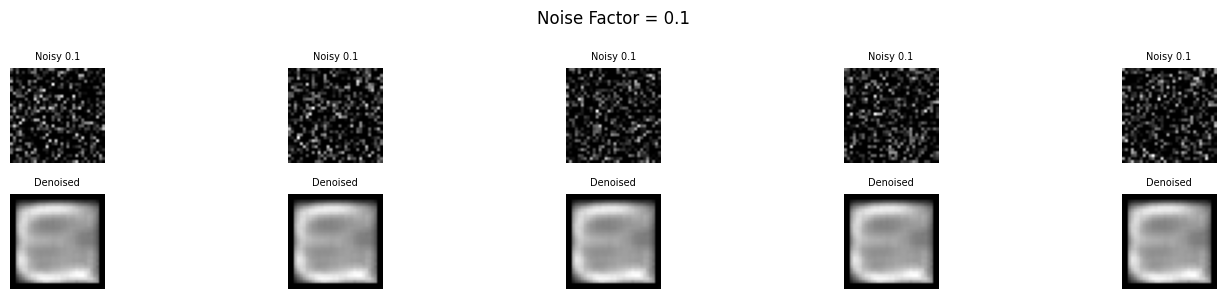


Noise Factor: 0.3


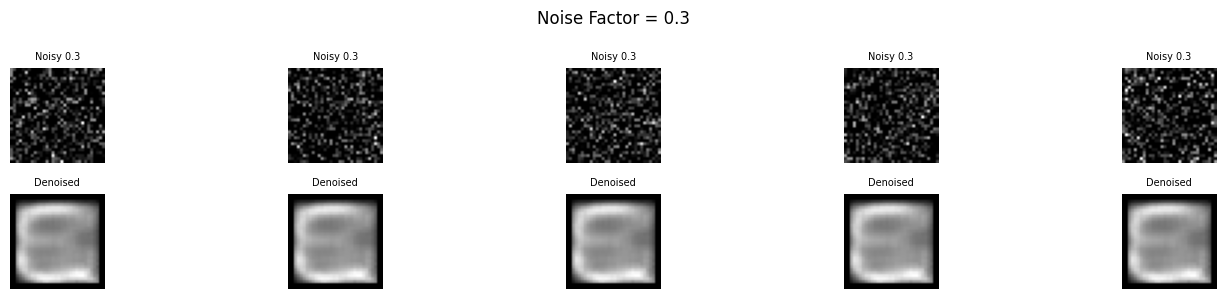


Noise Factor: 0.5


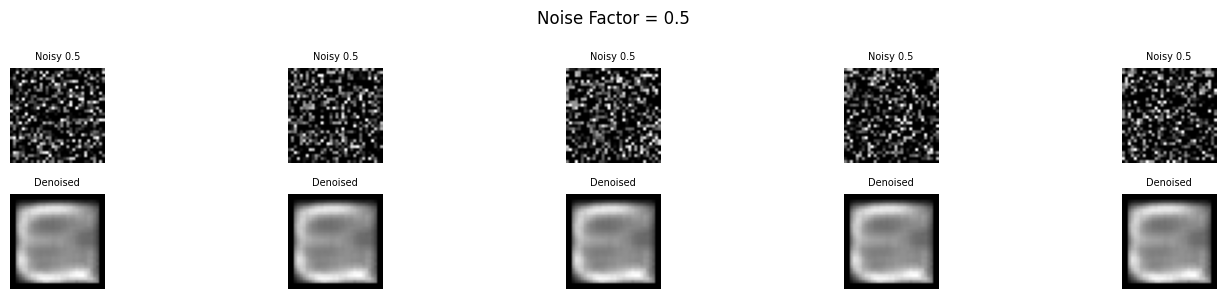


Noise Factor: 0.7


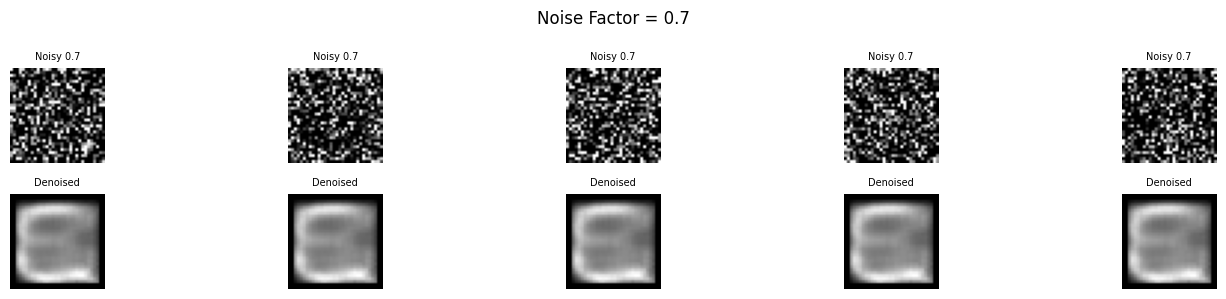

In [30]:
for noise_level in [0.1, 0.3, 0.5, 0.7]:
    x_test_exp = x_val + noise_level * np.random.normal(size=x_val.shape)
    x_test_exp = np.clip(x_test_exp, 0., 1.)

    denoised_exp = autoencoder.predict(x_test_exp, verbose=0)

    print(f"\nNoise Factor: {noise_level}")
    plt.figure(figsize=(15, 3))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test_exp[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title(f"Noisy {noise_level}", fontsize=7)
        plt.axis('off')

        plt.subplot(2, 5, i + 6)
        plt.imshow(denoised_exp[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Denoised", fontsize=7)
        plt.axis('off')

    plt.suptitle(f"Noise Factor = {noise_level}", fontsize=12)
    plt.tight_layout()
    plt.show()